In [3]:
# Classical computing modules
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pylatexenc
import pdflatex
from statistics import mode

# Dataset
from sklearn import datasets, preprocessing 
from sklearn.model_selection import train_test_split
# Quantum computing modules
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, qpy
from qiskit_aer import Aer, AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector, DensityMatrix, entropy, concurrence, partial_trace
from qiskit.circuit.library import UGate

In [4]:
def gate_V(n_qubits, params_j, entangled_params):
    
    # Creating the quantum circuit with the needed number of qubits
    qc_V = QuantumCircuit(n_qubits, name = "gate V")

    for t in range(n_qubits):
        # Add Hadamards to each qubit in the index register for superpositions
        qc_V.h(t)                                  

        # Add random rotations for randomizing the states
        qc_V.rz(params_j["rz1"][t], t)  
        qc_V.ry(params_j["ry"][t], t)
        qc_V.rz(params_j["rz2"][t], t)
        
    # Create an entangled state if "entangled" is one
    if entangled_params == 1:

        # Add CNOT between neighbouring qubits to create entanglement
        for i in range(n_qubits - 1):
            qc_V.cx(i, i+1)
    
    return qc_V

In [37]:
def gate_W(index_reg, train_reg):
    
    # Creating the quantum circuit with the needed registers
    qc_W = QuantumCircuit(name = "gate W")
    qc_W.add_register(index_reg)
    qc_W.add_register(train_reg)
    
    # Defining the necessary variables
    n_index = len(index_reg)
    n_train = len(train_reg)
    M = 2**n_index
    params = {}
    entangled_p = np.empty(M)
    
    for j in range(M):

        # Defining the necessary random parameters for the rotation gates
        params[j] = {"rz1": np.random.uniform(0, 2 * np.pi, size = n_train),
                     "ry": np.random.uniform(0, 2 * np.pi, size = n_train),
                     "rz2": np.random.uniform(0, 2 * np.pi, size = n_train),
                     }
        
        # Randomly choose between 0 and 1. If we choose 1, we create entangled states
        # If we choose 0, we create separable states
        
        entangled_p[j] = (np.random.randint(0, 2))
        

    for j, p in params.items():

        # Create bitstring for each training state
        bitstring = format(j, f"0{n_index}b")

        # Flips bits so that |j> = |111...1>
        for i, bit in enumerate(bitstring):
            if bit == "0":
                qc_W.x(index_reg[i])
       
        
        # Apply V only if the index register is |j>
        ctrl_gate = gate_V(n_train, p, entangled_p[j]).to_gate().control(n_index)
        qc_W.append(ctrl_gate, list(index_reg) + list(train_reg))

        # Uncompute bit flips so that the index register does not change
        for i, bit in enumerate(bitstring):
            if bit == "0":
                qc_W.x(index_reg[i])

        
    return entangled_p, qc_W
    

In [5]:
def gate_W2(M, train_reg):
    
    train_states = []
    # Defining the necessary variables
    n_train = len(train_reg)
    entangled_p = np.empty(M)

    for j in range(M):

        # Creating the quantum circuit with the needed registers
        qc_W = QuantumCircuit(name = "gate W")
        qc_W.add_register(train_reg)

        # Defining the necessary random parameters for the rotation gates
        params = {"rz1": np.random.uniform(0, 2 * np.pi, size = n_train),
                     "ry": np.random.uniform(0, 2 * np.pi, size = n_train),
                     "rz2": np.random.uniform(0, 2 * np.pi, size = n_train),
                     }
        
        # Randomly choose between 0 and 1. If we choose 1, we create entangled states
        # If we choose 0, we create separable states
        
        entangled_p[j] = np.random.randint(0, 2)

        # Apply V only if the index register is |j>      
        V_gate = gate_V(n_train, params, entangled_p[j]).to_gate()
        qc_W.append(V_gate, list(train_reg))

        train_states.append(qc_W)

        
    return entangled_p, train_states
    

In [ ]:
# # Define number of training states
# M = 100

# # Define n
# n_index = int(np.ceil(np.log2(M)))

# # Define the number of qubits we're working with
# n_qubits = 3

# # Define the four registers needed
# index_reg = QuantumRegister(n_index, 'i')
# train_reg = QuantumRegister(n_qubits, 'train')
# test_reg = QuantumRegister(n_qubits, 'test')
# B = QuantumRegister(1, 'B')

# # Create circuit
# qknn = QuantumCircuit()

# # Add registers to the circuit
# qknn.add_register(index_reg)
# qknn.add_register(train_reg)
# qknn.add_register(test_reg)
# qknn.add_register(B)

# # Create the gate W
# class_list, W = gate_W(index_reg, train_reg)

In [ ]:
# # Save class_list and W so we can keep using the same dataset
# np.save("Class list", class_list)

# with open("W_gate.qpy", "wb") as file:
#    qpy.dump(W, file)

In [15]:
# # Load gate W and add it to the circuit
# with open("W_gate.qpy", "rb") as handle:
#     qc = qpy.load(handle)

In [14]:
# Define number of training states
M = 100

# Define n
n_index = int(np.ceil(np.log2(M)))

# Define the number of qubits we're working with
n_qubits = 3

# Define the four registers needed
train_reg = QuantumRegister(n_qubits, 'train')
test_reg = QuantumRegister(n_qubits, 'test')
B = QuantumRegister(1, 'B')

# Create circuit
qknn = QuantumCircuit()

# Add registers to the circuit
qknn.add_register(train_reg)
qknn.add_register(test_reg)
qknn.add_register(B)

In [17]:
# Create the gate W
class_list2, W2 = gate_W2(2**n_index, train_reg)

In [18]:
# Save class_list and W so we can keep using the same dataset
np.save("Class list 2", class_list2)

with open("W_gate 2.qpy", "wb") as file:
   qpy.dump(W2, file)

In [19]:
# Load gate W and add it to the circuit
with open("W_gate 2.qpy", "rb") as handle:
    qc = qpy.load(handle)

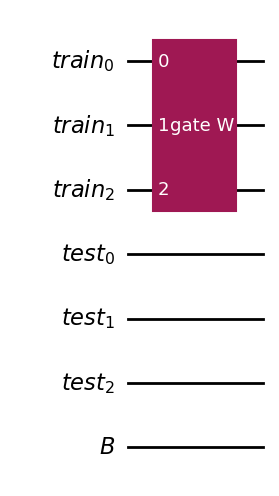

In [20]:
# Add W to the circuit
qknn.append(qc[0], list(train_reg))
qknn.draw("mpl")

In [ ]:
# Define the parameters to be used in gate V
params_j = {"rz1": np.random.uniform(0, 2 * np.pi, size = n_qubits),
                     "ry": np.random.uniform(0, 2 * np.pi, size = n_qubits),
                     "rz2": np.random.uniform(0, 2 * np.pi, size = n_qubits),
                     }
entangled_p_j = [np.random.random_integers(0, 1)]
    
# Create the gate V
V = gate_V(n_qubits, params_j, entangled_p_j)

C:\Users\lyrav\AppData\Local\Temp\ipykernel_48840\658771991.py:6: DeprecationWarning: This function is deprecated. Please call randint(0, 1 + 1) instead
  entangled_p_j = [np.random.random_integers(0, 1)]


In [19]:
# Save V
with open("V_gate.qpy", "wb") as file:
     qpy.dump(V, file)

In [46]:
from modules import swap_test

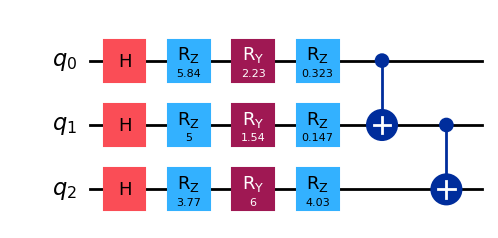

In [22]:
# Load gate V
with open("V_gate.qpy", "rb") as handle:
    qc2 = qpy.load(handle)

# Visualize gate V
qc2[0].draw("mpl")   

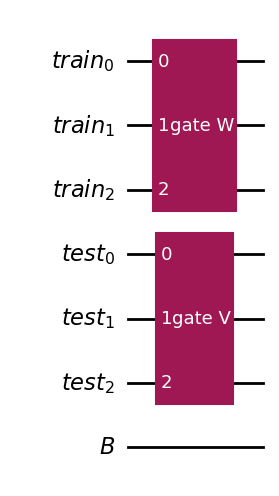

In [23]:
# Add V to the circuit
qknn.append(qc2[0], list(test_reg))
qknn.draw("mpl")